# Flujo y transporte conservativo de la especie $c_1= SO_4^{2-}$.

**Descripción**.

En esta notebook se plantea el problema de flujo de agua subterránea y transporte conservativo de la especie química $c_1= SO_4^{2-}$ y se resuelve usando MODFLOW 6 (GWF y GWT) en combinación de las herramientas de **FloPy**.

<a href="https://github.com/luiggix/RTWMA">RTWMA</a> © 2024-2026 by <a href="https://www.geofisica.unam.mx">IGF-UNAM</a> is licensed under <a href="https://creativecommons.org/licenses/by-nc/4.0/">CC BY-NC 4.0</a><img src="https://mirrors.creativecommons.org/presskit/icons/cc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/by.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;"><img src="https://mirrors.creativecommons.org/presskit/icons/nc.svg" alt="" style="max-width: 1em;max-height:1em;margin-left: .2em;">

# Planteamiento del problema.

El dominio es una columna 1D de longitud $L = 30 \text{ (m)}$, en dirección $x$, representando un acuífero de espesor y ancho unitarios, véase figura 1. 

<figure>
  <img src="../figures/c1_transporte.svg" width=600px alt="dominio de estudio y condiciones" />
  <figcaption>Figura 1. Dominio de estudio, condiciones iniciales y de frontera. El dominio es de tamaño $L = 30 \text{ (m)}$ y será dividido en $30$ celdas de $1\;\text{(m)}$ cada una de tal manera que $x_{_{12}}$ va del inicio del dominio al centro de la celda número $12$. </figcaption>
</figure>

Sobre este dominio ocurren dos procesos acoplados:

- Flujo de agua subterránea, gobernado por la carga hidráulica $h(x,t)$.
- Transporte de soluto, gobernado por la concentración $c_1(x,t)$, que se
  mueve por advección (arrastrado por el flujo de agua) y dispersión
  hidrodinámica.

El campo de flujo (carga $h$ y velocidad $v$) controla el transporte, pero el soluto no modifica la
densidad ni la viscosidad del agua.

El problema se va a resolver en un periodo de $40$ días, con un paso de tiempo constante de $1$ día ($40$ pasos de tiempo).

## Modelo de flujo de agua subterránea.

Para un acuífero 1D, confinado, con conductividad hidráulica $K_x$ y
coeficiente de almacenamiento específico $S_s$, la ecuación de flujo es:

$$
S_s \frac{\partial h}{\partial t} = \frac{\partial}{\partial x}
\left( K_x \frac{\partial h}{\partial x} \right) + q_s(x,t)
$$

donde $q_s(x,t)$ representa fuentes o sumideros volumétricos de agua por
unidad de volumen (p. ej. un pozo).


<div class="alert alert-info">
    
**NOTA**.

En MODFLOW 6 se utiliza $Q^\prime_s$ para representar el flujo volumétrico por unidad de volumen en una fuente o sumidero y $SS$ para representar el almacenamiento específico. En este documento usaremos $q_s$ y $S_s$ para dichas cantidades respectivamente.

</div>
    


**Condiciones de frontera:**

$$
\left.\frac{\partial h}{\partial x}\right|_{(0,t)} = 0
\qquad\text{(frontera cerrada / flujo nulo en } x=0\text{)}
$$

$$
h(x_{_{L}}, t) = 1.0 \qquad\text{(carga fija en el extremo } x=x_{_{L}}\text{)}
$$

**Condición inicial:** 

$$
h(x,t_0) = 1.0 \qquad\text{(m)}
$$

## Modelo de transporte de soluto.

Para la especie $c_1$, con porosidad $\theta$, coeficiente de dispersión hidrodinámica $D_{xx}$ y descarga específica $q_x$ la ecuación de transporte se escribe como:

$$
- \frac{\partial (\theta c_1)}{\partial t}
- \frac{\partial (q_x c_1)}{\partial x}
+ \frac{\partial}{\partial x}\left(\theta D_{xx} \frac{\partial c_1}{\partial x}\right)
+ q_s c_s = 0
$$

con $D_{xx} = \alpha_L |v_x| + D^{*}$ ($\alpha_L$: dispersividad longitudinal,
$D^{*}$: difusión molecular efectiva), $v_x = q_x / \theta $ ($v_x$: velocidad de
poro de flujo de agua) y $c_s$ es la concentración volumétrica de soluto en la fuente/sumidero.

**Condiciones de frontera:**

$$
c_1(x_{_{1}}, t) = 1.000329 \qquad\text{(concentración fija en } x=x_{_{1}})
$$

$$
D_x \left.\frac{\partial c_1}{\partial x}\right|_{(L,t)} = 0
\qquad\text{(flujo dispersivo nulo en la salida } x=L )
$$

**Condición inicial:**

$$
c_1(x,t_0) = 1.000329 \quad \forall\, x \neq x_{_{12}}
$$
$$
c_1(x_{_{12}}, t_0) = 200.0
$$

En el instante inicial la concentración es igual a un valor de $1.000329$ 
en todo el dominio, excepto en el punto $x_{_{12}}$ donde existe un valor 
en dicha celda de $200.0$ que representa una masa de soluto
ya presente en el medio (p. ej. un derrame o inyección previa) que a partir
de $t_0$ comenzará a migrar y dispersarse bajo la acción del flujo.


# Solución numérica con MODFLOW 6.

Para realizar una simulación en MODFLOW 6, de flujo o de transporte, se requiere generar una estructura como la que se muestra en la figura 2. Dado que esta versión del software es orientada a objetos, cada bloque que se muestra en la figura corresponde a un objeto, con sus propios métodos y atributos. Obsérvese que las simulaciones, en este caso, se realizan de manera separada, es decir, primero se calcula el flujo generando archivos de salida (`.hds`, `.bud`) y posteriormente se simula el transporte utilizando la información del flujo previamente calculada. 

<figure>
  <img src="../figures/mf6_flujo_transporte.svg" width=650px alt="dominio de estudio y condiciones" />
  <figcaption>Figura 2. En una simulación de MODFLOW 6 inicialmente se agregan las siguientes cuatro componentes (que en términos de la implementación son objetos): para controlar la simulación, para la discretización temporal, para la de solución numérica y para el modelo que se va a simular. Al objeto del modelo posteriomente se le agregan paquetes (que también son objetos) que definen el problema a resolver, véase (Langevin et al. 2023). </figcaption>
</figure>

## Uso de FloPy.
La solución numérica se realiza con MODFLOW 6 usando las herramientas que provee la bibliteca FloPy. 
Es importante notar que FloPy es una biblioteca que permite 1) generar los archivos de entrada para una simulación, 2) realizar la simulación ejecutando el código compilado de Fortran de MODFLOW 6 y finalmente 3) analizar y visualizar los resultados de la simulación. La figura 3 muestra este proceso.

<figure>
  <img src="../../figures/modflow_flopy.svg" width=650px alt="dominio de estudio y condiciones" />
  <figcaption>Figura 3. Simulación usando MODFLOW 6 en combinación con FloPy. Flopy permite generar los archivos de entrada para MODFLOW 6; posteriormente se ejecuta MODFLOW 6 a través de Flopy y se generan los archivos de salida. Esta salida se analiza y visualiza con las herramientas de FloPy y otras más que se pueden usar desde Python. </figcaption>
</figure>

## Definición de datos iniciales.

El primer paso es importar las bibliotecas necesarias para realizar la simulación:

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import flopy
import xmf6

### Discretización espacial.

El dominio se discretiza en $30$ celdas equiespaciadas como se muestra en la figura 4.

<figure>
  <img src="../..//figures/spatial_dis.svg" width=600px alt="dominio de estudio y condiciones" />
  <figcaption>Figura 4. El espacio se discretiza en 30 celdas. Se resaltan las celdas de la frontera y aquellas donde se tiene una condición inicial de concentración alta. </figcaption>
</figure>

La siguiente tabla muestra los valores para la discretización espacial definidos en términos de la notación de MODFLOW 6 y FloPy. La columna **Variable** indica la(s) variable(s) donde se almacena cada valor en la implementación.

|Parámetro | Valor | Unidades | Variable |
|---:|:---:|:---:|:---|
|Length of system (rows) | $30.0$ | m | |
|Number of layers | $1$ | | `dis["nlay"]`|
|Number of rows | $1$ | | `dis["nrow"]`|
|Number of columns | $30$ | | `dis["ncol"]`|
|Column width | $1.0$ | m | `dis["delr"]`|
|Row width | $1.0$ | m | `dis["delc"]`|
|Top of the model | $1.0$ | m | `dis["top"]`|
|Layer bottom elevation (cm) | $0$ | m | `dis["botm"]`|

In [2]:
# Discretización espacial
nlay = 1
nrow = 1
ncol = 30
delr = 1.0
delc = 1.0
top  = 1.0
botm = 0.0

dis = {
    'units' : "meters",
    'nlay': nlay, 
    'nrow': nrow, 
    'ncol': ncol,
    'delr': delr, 
    'delc': delc, 
    'top' : top, 
    'botm': botm 
}
xmf6.nice_print("Spatial discretization", dis)


Spatial discretization
――――――――――――――――――――――
units = meters
 nlay = 1
 nrow = 1
 ncol = 30
 delr = 1.0
 delc = 1.0
  top = 1.0
 botm = 0.0
――――――――――――――――――――――


### Discretización del tiempo.

Como se mencionó en el planteamiento del problema, se va a resolver en un periodo de $40$ días con un paso de tiempo constante de $1$ día ($40$ pasos de tiempo). Sin embargo, debido a que el flujo se mantiene constante durante toda la simulación, se utiliza un solo paso de tiempo de $40$ días para resolver el flujo. 

|Parámetro | Valor| Unidades | Variable |
|---:|:---:|:---:|:---|
|Number of stress periods (NPER) | $1$ | | `tdis["nper"]` |
|Total time | $40$ | days | `tdis["perioddata"][0][0]` |
|Number of time steps (NSTP) | $1$ | | `tdis["perioddata"][0][1]` |
|Multiplier (TSMULT)| $1$ | | `tdis["perioddata"][0][2]` |


<div class="alert alert-info">
    
**NOTA**.

El valor del parámetro NSTP será cambiado a $40$ cuando se resuelva el transporte.
</div>

In [3]:
# Discretización del tiempo para el flujo 
tdis = {
    'units': "days",
    'nper' : 1,
    'perioddata': [(40.0, 1, 1.0)] #PERLEN, NSTP, TSMULT
}
xmf6.nice_print("Time discretization (flow)", tdis)


Time discretization (flow)
――――――――――――――――――――――――――
     units = days
      nper = 1
perioddata = ―― data array ――
           = (40.0, 1, 1.0)
――――――――――――――――――――――――――


### Parámetros físicos.

Para resolver el problema necesitamos definir varios parámetros físicos. Para ello tomaremos en cuenta que el flujo es estacionario, por lo que solo se resuelve una vez en el lapso de $40$ días, esto implica además que no se requiere definir el coeficiente de almacenamiento específico $S_s$. Recordemos que en la celda $1$ se agrega un pozo de inyección, que es coherente con el hecho de que ahí se especifica una descarga específica $q_s$ y una concentración de entrada $c_s = c_1(x_{_{1}},t)=1.000329$, esto representa el agua que ingresa al sistema y empuja el soluto hacia $x_{_{L}}$. Las condiciones iniciales y de frontera se describen en la figura 1. En la siguiente tabla se describen todos los parámetros requeridos, comenzando primero con los de flujo y posteriormente con los de transporte.

|Parámetro | Símbolo | Valor | Unidades | Variable |
|---:|:--:|:---:|:---:|:---|
|Initial head | $h(x, t_0)$| $1.0$ | m | `phys["initial_head"]` |
|Head boundary condition (type I) | $h({x_{_{L}}, t})$ | 1.0 | m | `phys["bc_head_t1"]` |
|Hydraulic conductivity | $K_x$ |$1.0$| m d$^{-1}$ | `phys["hydraulic_conductivity"]` |
|Specific discharge | $q_s$ |$0.2$| m d$^{-1}$ | `phys["specific_discharge"]` |
|Source concentration | $c_s$ | $1.0000329$| unitless | `phys["source_concentration"][0]` |
|Well inyection | $q_s c_s$ | -- | m d$^{-1}$ | `phys["well"]`|
|Porosity | $\theta$ | $0.5$ | unitless |  `phys["porosity"]` |
|Initial concentration | $c_1(x, t_0)$ |$1.0000329$ | unitless | `phys["initial_concentration"]` |
|Initial concentration pulse | $c_1(x_{_{12}}, t_0)$ |$200.0$ | unitless | `phys["initial_concentration"][11]` |
|Concentration boundary condition (type I) | $c_1(x_{_{1}}, t)$ | $1.0000329$| unitless | `phys["bc_conc_t1"][0]` |
|Longitudinal Dispersivity | $\alpha_L$ |$0.2$ | m  | `phys["longitudinal_dispersivity"]` |
|Dispersion coefficient | $D_{xx}$ | $1.0$ | m$^{2}$ d$^{-1}$| `phys["dispersion_coefficient"]` |

In [4]:
# Arreglo para la condición inicial
c1_ini = np.full((nlay,nrow,ncol), 1.0000329) # En todo el dominio
c1_ini[0, 0, 11] = 200.0  # Pulso en x_L

print("Array info: c1")
xmf6.info_array(c1_ini)

phys = dict(
    initial_head = 1.0,
    bc_head_t1 = [("CHD-1" , [(0, 0, dis['ncol'] - 1), 1.0])],
    hydraulic_conductivity = 1.0, 
    specific_discharge = 0.2, 
    source_concentration = 1.0000329,
    porosity = 0.5,
    initial_concentration = c1_ini,
    bc_conc_t1 = [("CNC-1", [(0, 0, 0), 1.0000329])],
    longitudinal_dispersivity = 0.2,
    dispersion_coefficient = 1.0 
)
# Agregamos la información del pozo
q = phys["specific_discharge"] * dis['delc'] * dis['delr'] * dis['top']
phys["well"] = [("WEL-1", "AUX", "CONCENTRATION"), ((0, 0, 0), q, phys["source_concentration"])]

xmf6.nice_print("Physical parameters", phys)

Array info: c1
 tipo  : <class 'numpy.ndarray'> 
 dtype : float64 
 dim   : 3 
 shape : (1, 1, 30) 
 size(bytes) : 8 
 size(elements) : 30

Physical parameters
―――――――――――――――――――
             initial_head = 1.0
               bc_head_t1 = ―― data array ――
                          = ('CHD-1', [(0, 0, 29), 1.0])
   hydraulic_conductivity = 1.0
       specific_discharge = 0.2
     source_concentration = 1.0000329
                 porosity = 0.5
    initial_concentration = ―― data array ――
                          = [[  1.0000329   1.0000329   1.0000329   1.0000329   1.0000329   1.0000329
    1.0000329   1.0000329   1.0000329   1.0000329   1.0000329 200.
    1.0000329   1.0000329   1.0000329   1.0000329   1.0000329   1.0000329
    1.0000329   1.0000329   1.0000329   1.0000329   1.0000329   1.0000329
    1.0000329   1.0000329   1.0000329   1.0000329   1.0000329   1.0000329]]
               bc_conc_t1 = ―― data array ――
                          = ('CNC-1', [(0, 0, 0), 1.0000329])
longitu

### Rutas, nombres de archivos y otros.

Definimos un diccionario con información de la ruta al ejecutable de MODFLOW y con los nombres de los modelos de flujo y transporte así como los directorios del espacio de trabajo.

In [5]:
paths = dict(
    # Ejecutable de MODFLOW 6
    mf6_exe = r"C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6",
    #
    # Nombre de los modelos y espacios de trabajo
    flow_name = "flow",
    flow_ws = "output_c1/gwf",
    tran_name = "transport",
    tran_ws = "output_c1/gwt"
)
xmf6.nice_print("Paths, files and more ...", paths)


Paths, files and more ...
―――――――――――――――――――――――――
  mf6_exe = C:\Users\luiggi\Documents\GitSites\mf6_tutorial\mf6\windows\mf6
flow_name = flow
  flow_ws = output_c1/gwf
tran_name = transport
  tran_ws = output_c1/gwt
―――――――――――――――――――――――――


## Construcción del modelo de flujo con GWF.

Para realizar una simulación de flujo con GWF de MODFLOW 6 se requiere construir una estructura como la que se muestra en la figura 2. Dicha estructura se construye usando FloPy con las clases `flopy.mf6.MFSimulation`, `flopy.mf6.ModflowTdis`, `flopy.mf6.ModflowIms` y `flopy.mf6.ModflowGwf`. A partir de estas clases se crean objetos con los atributos requeridos por la simulación. En la siguiente celda se realiza esta implementación:

In [6]:
# Creación del objeto de la simulación de flujo
o_sim = flopy.mf6.MFSimulation(
    sim_name = paths["flow_name"], 
    sim_ws = paths["flow_ws"], 
    exe_name = paths["mf6_exe"], 
    version="mf6"
)

# Creación del objeto de la discretización del tiempo
o_tdis = flopy.mf6.ModflowTdis(
    o_sim,
    time_units = tdis["units"],
    nper = tdis["nper"],
    perioddata = tdis["perioddata"],
)

# Creación del objeto de la solución del sistema lineal
o_ims = flopy.mf6.ModflowIms(
    o_sim
)

# Creación del objeto del modelo de flujo
o_gwf = flopy.mf6.ModflowGwf(
    o_sim, 
    modelname = paths["flow_name"], 
    save_flows = True
)

### Paquetes.

Para resolver el problema de flujo antes planteado se requiere de agregar paquetes al modelo que está representado por el objeto `o_gwf`. En este caso requerimos los siguientes paquetes:

- `DIS`: Discretización espacial de tipo estructurada.
- `NPF`: Propiedades del flujo, particularmente la conductividad hidráulica $K_x$.
- `IC`: Definición de las condiciones iniciales de la carga hidráulica.
- `CHD`: Condición de frontera de carga hidráulica fija $h(x_{_{L}},t)=1.0$.
- `WEL`: Pozo de inyección de $q_s c_s$ en $x_{_{1}}$.
- `OC` : Definición de los archivos para almacenar los resultados de la simulación.
- No se define el paquete `STO` debido a que el flujo se resuelve en régimen
  permanente.
- El límite izquierdo ($x=0$) no recibe ninguna condición de frontera, por
  lo que MODFLOW 6 le asigna flujo nulo por defecto:
  $\partial h/\partial x(0,t)=0$ se cumple automáticamente.


In [7]:
# Agregamos el paquete DIS para la discretización espacial estructurada
o_dis = flopy.mf6.ModflowGwfdis(
    o_gwf,
    nlay = dis["nlay"], 
    nrow = dis["nrow"], 
    ncol = dis["ncol"],
    delr = dis["delr"], 
    delc = dis["delc"], 
    top  = dis["top"], 
    botm = dis["botm"],
)

# Agregamos el paquete NPF para las prop. del flujo
o_npf = flopy.mf6.ModflowGwfnpf(
    o_gwf,
    k = phys["hydraulic_conductivity"], 
    icelltype=0, 
    save_specific_discharge = True,
    save_saturation=True
)

# Agregamos el paquete IC para las condiciones iniciales
o_ic = flopy.mf6.ModflowGwfic(
    o_gwf, 
    strt = phys["initial_head"]
)

# Agregamos el paquete CHD para definir la carga fija (condición de frontera)
o_chd = flopy.mf6.ModflowGwfchd(
    o_gwf,
    stress_period_data = [phys["bc_head_t1"][0][1],],
    pname = phys["bc_head_t1"][0][0],
)

# Agregamos el paquete WEL para definir un pozo de inyección
# Pozo de inyeccion en x1 (con concentracion auxiliar para el acople con GWT)
o_wel = flopy.mf6.ModflowGwfwel(
    o_gwf,
    stress_period_data = [phys["well"][1],],
    auxiliary = [phys["well"][0][2]],
    pname = phys["well"][0][0],
)

# Agregamos el paquete OC para almacenar la salida
oc_gwf = flopy.mf6.ModflowGwfoc(
    o_gwf,
    head_filerecord=f"{paths["flow_name"]}.hds",
    budget_filerecord=f"{paths["flow_name"]}.bud",
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
)

### Escritura de archivos y ejecución.

In [8]:
# Escritura de los archivos de entrada para la simulación de flujo
o_sim.write_simulation(silent = False)

# Ejecución de la simulación de flujo.
o_sim.run_simulation(silent = False)

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model flow...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package ic...
    writing package chd-1...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 1 based on size of stress_period_data
    writing package wel-1...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 1 based on size of stress_period_data
    writing package oc...
FloPy is using the following executable to run the model: ..\..\..\..\..\..\mf6_tutorial\mf6\windows\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.1 02/10/2025

   MODFLOW 6 compiled Feb 10 2025 17:37:25 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                

(True, [])

### Revisión de resultados.

Los resultados de la simulación de flujo quedan almacenados en archivos con extensión `.hds` y `.bud` que están en formato binario. FloPy ofrece herramientas para extraer esta información y visualizarla. La biblioteca xmf6 encapsula estas herramientas en funciones que permite un uso más simple. A continuación extraemos la información de la carga hidráulica $h$ y de la descarga específica $q$.

In [9]:
# Objeto para acceder a los resultados de la carga hidráulica.
o_head = o_gwf.output.head()

# Tiempos calculados para el flujo.
times_h = np.array(o_head.get_times())

# Recuperamos la carga hidráulica del paso 40.
head = o_head.get_data(totim=40)[0, 0, :]

# Objeto para acceder a los resultados de la descarga específica.
budget = o_gwf.output.budget()

# Recuperamos la descarga específica del paso 40.
spdis = budget.get_data(totim=40, text="DATA-SPDIS")[0]
qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, o_gwf)

# Recuperamos las coordenadas de los centros de las celdas de la malla
x, y, z = o_gwf.modelgrid.xyzcellcenters

# Diccionario para imprimir la información en pantalla
flow_dict = dict(
    xcoord = x,
    times = [times_h],
    head = [head],
    qx = qx[:,0],
)
xmf6.nice_print("Head", flow_dict)


Head
――――
xcoord = ―― data array ――
       = [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5]
 times = ―― data array ――
       = [40.]
  head = ―― data array ――
       = [6.8 6.6 6.4 6.2 6.  5.8 5.6 5.4 5.2 5.  4.8 4.6 4.4 4.2 4.  3.8 3.6 3.4
 3.2 3.  2.8 2.6 2.4 2.2 2.  1.8 1.6 1.4 1.2 1. ]
    qx = ―― data array ――
       = [0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2
 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2]
――――


## Construcción del modelo de transporte conservativo con GWT

De igual manera que en el caso del flujo, para realizar la simulación del transporte conservativo se debe construir una estructura similar a la mostrada en la figura 2. Debido a que esta es una simulación separada de la del flujo, reutilizaremos algunos objetos con atributos diferentes. Comenzamos con la discretización del tiempo; en este caso se realizan $40$ pasos de un día cada uno, entonces el diccionario `tdis` lo modificamos como sigue:

In [10]:
# Discretización del tiempo para el transporte
tdis = {
    'units': "days",
    'nper' : 1,
    'perioddata': [(40.0, 40, 1.0)] #PERLEN, NSTP, TSMULT
}
xmf6.nice_print("Time discretization (transport)", tdis)


Time discretization (transport)
―――――――――――――――――――――――――――――――
     units = days
      nper = 1
perioddata = ―― data array ――
           = (40.0, 40, 1.0)
―――――――――――――――――――――――――――――――


Entonces la estructura inicial de la simulación se realiza como sigue:

In [11]:
# Creación del objeto de la simulación de flujo
o_sim = flopy.mf6.MFSimulation(
    sim_name = paths["tran_name"], 
    sim_ws = paths["tran_ws"], 
    exe_name = paths["mf6_exe"], 
    version="mf6"
)

# Creación del objeto de la discretización del tiempo
# OJO: aquí cambio el número de pasos de simulación.
o_tdis = flopy.mf6.ModflowTdis(
    o_sim,
    time_units = tdis["units"],
    nper = tdis["nper"],
    perioddata = tdis["perioddata"],
)

# Creación del objeto de la solución del sistema lineal
# En este caso se requiere de un "solver" para sistemas no simétricos
o_ims = flopy.mf6.ModflowIms(
    o_sim,
    complexity="SIMPLE",
    linear_acceleration="BICGSTAB",
    outer_dvclose=1e-8,
    inner_dvclose=1e-8,
)

# Creación del objeto del modelo de transporte
o_gwt = flopy.mf6.ModflowGwt(
    o_sim, 
    modelname = paths["tran_name"], 
    save_flows = True
)

### Paquetes.

Para resolver el problema de transporte se requiere agregar paquetes al modelo que está representado por el objeto `o_gwt`. En este caso se necesita de lo siguiente:

- `DIS`: Discretización espacial de tipo estructurada. Se usa la misma que se usó para el flujo.
- `IC`: Condición inicial $c_1(x,t_0)$ que consiste en un valor constante en todo el dominio
  y el pulso puntual en $x_{_{12}}$.
- `ADV` : Advección con el esquema `TVD`.
- `DSP` : Dispersión, se define el coeficiente $\alpha_L$ (dispersión longitudinal) .
- `MST`: Se define la porosidad $\theta$.
- `CNC`: Condición de frontera de concentración fija $c_1(x_{_{1}},t)=1.000329$.
- En $x_{_{L}}$ no se define `CNC`: MODFLOW 6 aplica de forma natural un
  gradiente dispersivo nulo en la celda de salida, es decir
  $D_x\,\partial c_1/\partial x(L,t)=0$ se cumple automáticamente.
- `FMI` : Le indica a la simulación de dónde leer las cargas (`GWFHEAD`) y los caudales
(`GWFBUDGET`) que ya fueron calculados por la simulación de flujo anterior. 
- `SSM`: vincula la concentración auxiliar del pozo `WEL-1` con el
  transporte (requerido por MODFLOW 6 cuando el modelo de flujo tiene
  paquetes de frontera).

In [12]:
# Agregamos el paquete DIS para la discretización espacial estructurada
o_dis = flopy.mf6.ModflowGwfdis(
    o_gwt,
    nlay = dis["nlay"], 
    nrow = dis["nrow"], 
    ncol = dis["ncol"],
    delr = dis["delr"], 
    delc = dis["delc"], 
    top  = dis["top"], 
    botm = dis["botm"],
)

# Agregamos el paquete IC para las condiciones iniciales
# Condicion inicial: c1(x,t0) = 1.000329 en todo el dominio,
# excepto en x12 donde c1(x_12,t0) = 200.0
o_ic = flopy.mf6.ModflowGwtic(
    o_gwt, 
    strt = phys["initial_concentration"]
)

# Agregamos el paquete ADV para seleccionar el esquema de advección
o_adv = flopy.mf6.ModflowGwtadv(
    o_gwt, 
    scheme = "TVD"
)

# Agregamos el paquete DSP para seleccionar el modelo de dispersión
o_dsp = flopy.mf6.ModflowGwtdsp(
    o_gwt, 
    xt3d_off = True,
    alh = phys["longitudinal_dispersivity"], 
    ath1 = phys["longitudinal_dispersivity"], 
)

# Agregamos el paquete MST para definir la porosidad
o_mst = flopy.mf6.ModflowGwtmst(
    o_gwt, 
    porosity = phys["porosity"]
)

# Agregamos el paquete CNC para definir una concentracion fija 
# c1(x1,t) = 1.000329
o_cnc = flopy.mf6.ModflowGwtcnc(
    o_gwt,
    stress_period_data = [phys["bc_conc_t1"][0][1]],
    pname = phys["bc_conc_t1"][0][0],
)

# Agregamos el paquete FMI para enlazar la solución del flujo con la de transporte
path_flow = os.path.join(os.getcwd(), paths["flow_ws"], paths["flow_name"])
o_fmi = flopy.mf6.ModflowGwtfmi(
    o_gwt, 
    packagedata = [("GWFHEAD", f"{path_flow}.hds", None),
                   ("GWFBUDGET", f"{path_flow}.bud", None),
                  ],
    flow_imbalance_correction=True
)

# Agregamos el paquete SSM para vincular la concentración auxiliar del 
# pozo WEL-1 con el transporte
o_ssm = flopy.mf6.ModflowGwtssm(
    o_gwt, 
    sources = [phys["well"][0]]
)

# Agregamos el paquete OC para almacenar la salida
oc_gwt = flopy.mf6.ModflowGwtoc(
    o_gwt,
    concentration_filerecord=f"{paths["tran_name"]}.ucn",
    budget_filerecord=f"{paths["tran_name"]}.cbc",
    saverecord=[("CONCENTRATION", "ALL"), ("BUDGET", "ALL")],
)

### Escritura de archivos y ejecución.

In [13]:
# Escritura de los archivos de entrada para la simulación.
o_sim.write_simulation(silent = False)

# Ejecución de la simulación de flujo.
o_sim.run_simulation(silent = False)

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model transport...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package adv...
    writing package dsp...
    writing package mst...
    writing package cnc-1...
INFORMATION: maxbound in ('gwt6', 'cnc', 'dimensions') changed to 1 based on size of stress_period_data
    writing package fmi...
    writing package ssm...
    writing package oc...
FloPy is using the following executable to run the model: ..\..\..\..\..\..\mf6_tutorial\mf6\windows\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.1 02/10/2025

   MODFLOW 6 compiled Feb 10 2025 17:37:25 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 2

(True, [])

### Revisión de resultados.

Los resultado de la simulación de transporte quedan almacenados en archivos con extensión `.ucn` y `.cbd` en formato binario. En este caso usamos las herramientas que ofrece FloPy ofrece para extraer esta información.

In [14]:
# Objeto para recuperar los resultados del transporte
o_conc = o_gwt.output.concentration()

# Recuperamos los pasos de tiempo calculados
times_c = np.array(o_conc.get_times())

# Recuperamos la información del último paso de tiempo
c1_40 = o_conc.get_data(totim=times_c[-1]).flatten()


# Diccionario para imprimir la información en pantalla
tran_dict = dict(
    xcoord = x,
    times = [times_c],
    conc = [c1_40]
)
xmf6.nice_print("c1 concentration", tran_dict)


c1 concentration
――――――――――――――――
xcoord = ―― data array ――
       = [ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5]
 times = ―― data array ――
       = [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40.]
  conc = ―― data array ――
       = [ 1.0000329   1.0000329   1.0000329   1.0000329   1.00003292  1.00003302
  1.00003351  1.00003595  1.00004722  1.00009598  1.00029235  1.00102549
  1.00355206  1.01155524  1.03476468  1.0961663   1.24387703  1.56605862
  2.20146792  3.33133076  5.13660142  7.71610804 10.98840382 14.62389229
 18.07048461 20.64610259 21.65822289 21.39315487 20.17483738 17.15004607]
――――――――――――――――


# Visualización de resultados.

La visualización de los resutados de flujo y transporte los realizamos usando FloPy en combinación con matplotlib.

In [15]:
# Usamos LaTeX para los tectos de la figura.
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",  # Uses standard Computer Modern font
    "font.serif": ["Computer Modern Roman"],
})

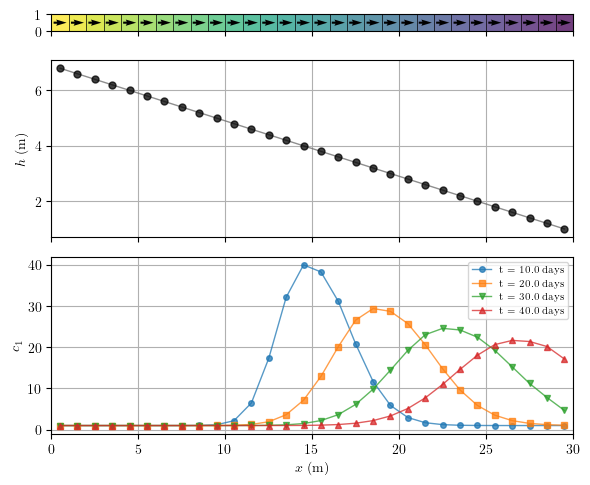

In [16]:
# --- Definición de la figura. Se definen tres gráficas 
fig, (ax1, ax2, ax3) = plt.subplots(3,1, sharex = True, figsize =(6,5),
                                    height_ratios=[0.1, 0.5, 0.5])

# --- Gráfica 1. Carga hidráulica y descarga específica sobre la malla
ax1.set_aspect('equal')
pmv = flopy.plot.PlotMapView(model = o_gwf, ax = ax1)
pmv.plot_grid(colors = 'k', lw = 0.5, ls="-")
pmv.plot_array(head, cmap = "viridis", alpha=0.5)
pmv.plot_vector(qx, qy, scale=40, pivot="mid", width=0.004, normalize=True, color="k")

# --- Gráfica 2. Carga hidráulica vs posición
ax2.plot(x[0], head, marker="o", lw =1.0, c = "dimgray", label = 'Head', 
         mec="black", mfc="black", markersize="5", alpha = 0.75, )
ax2.set_xlim(0, 30)
ax2.set_ylabel("$h$ (m)")
ax2.grid()

# --- Gráfica 3. Concentración para diferentes pasos de tiempo
marker = ["o", "s", "v", "^"] 
for i, t in enumerate(times_c[9::10]):
    c1 = o_conc.get_data(totim=t).flatten()
    ax3.plot(x[0], c1, ls ="-", lw = 1.0, label=f"t = {t} days", zorder=2,
             marker = marker[i], markersize="4", alpha = 0.75)
ax3.set_xlabel("$x$ (m)")
ax3.set_ylabel("$c_1$")
ax3.legend(fontsize=7)
ax3.grid()

plt.tight_layout()
plt.show()

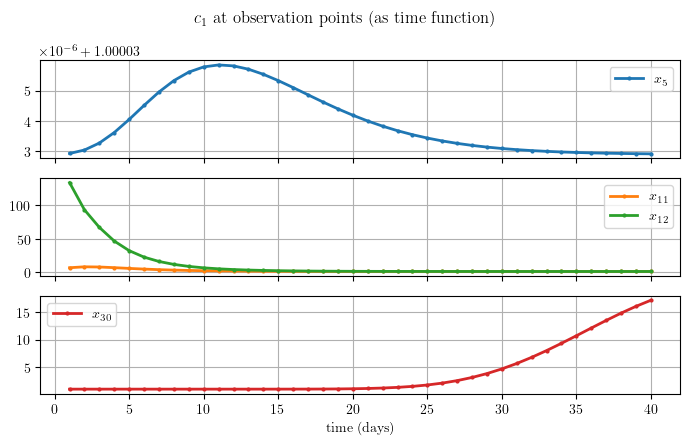

In [17]:
c_5 = np.array([o_conc.get_data(totim=t)[0, 0, 4] for t in times_c])
c_11 = np.array([o_conc.get_data(totim=t)[0, 0, 10] for t in times_c])
c_12 = np.array([o_conc.get_data(totim=t)[0, 0, 11] for t in times_c])
c_30 = np.array([o_conc.get_data(totim=t)[0, 0, 29] for t in times_c])

fig, ax = plt.subplots(3,1, sharex = True, figsize=(7, 4.5))
fig.suptitle("$c_1$ at observation points (as time function)")

ax[0].plot(times_c, c_5, lw=2,marker="o",markersize="2",c="C0",label="$x_5$")
ax[0].grid()
ax[0].legend()

ax[1].plot(times_c, c_11, lw=2,marker="o",markersize="2",c="C1",label="$x_{11}$")
ax[1].plot(times_c, c_12, lw=2,marker="o",markersize="2",c="C2",label="$x_{12}$")
ax[1].grid()
ax[1].legend()

ax[2].plot(times_c, c_30, lw=2,marker="o",markersize="2",c="C3",label="$x_{30}$")
ax[2].grid()
ax[2].legend()
ax[2].set_xlabel("time (days)")
plt.tight_layout()
plt.show()

# Referencias.

* Langevin, C. D., Hughes, J. D., Provost, A. M., Russcher, M. J., & Panday, S. (2023). MODFLOW as a configurable Multi‐Model Hydrologic Simulator. Ground Water. https://doi.org/10.1111/gwat.13351.
